# Artificial Intelligence in the Research Literature since 2000: Evidence from the OpenAlex API

DATASCI 530 — Assignment 3
Author: *Rola*
Data: OpenAlex Works API (`https://api.openalex.org/works`), retrieved 28 September 2026

## Summary of findings

> ✏️ *To write in your own words.*

## Data and methodology

> ✏️ *To write in your own words.*

## 1. Setup

In [1]:
import os                  # check whether a saved JSON file exists
import json                # read and write JSON files
import time                # retrieval date + short pause between requests
import requests            # send requests to the OpenAlex API
import jmespath            # extract values from nested JSON (Lecture 5b)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"font.size": 11, "axes.titlesize": 13, "axes.labelsize": 11,
                     "legend.fontsize": 10, "figure.dpi": 110})

In [2]:
# ---- API settings -----------------------------------------------------------
url_openalex_works = "https://api.openalex.org/works"    # Works endpoint
folder_cache       = "json_files/openalex/"              # every API response is saved here
refresh_cache      = False                               # True = download every response again
api_key            = os.environ.get("OPENALEX_API_KEY")  # optional free key; None if not set

os.makedirs(folder_cache, exist_ok = True)

# ---- Definition of an "AI publication" --------------------------------------
# The double quotes make OpenAlex search for the exact phrase in the title.
filter_ai = 'title.search:"artificial intelligence"'

# ---- One fixed color per search term (colorblind-safe palette) ---------------
dict_colors = {"artificial intelligence": "#2a78d6",
               "LLM":                     "#eb6834",
               "GPT":                     "#1baf7a",
               "machine learning":        "#eda100"}

# ---- Log of every request (printed in the appendix) --------------------------
list_requests = []

### 1.1 Helper functions

> ✏️ *To write in your own words.*

In [3]:
def get_openalex(parameters, file_name):
    # Returns the API response for `parameters` as a dictionary.
    # The response is saved to json_files/openalex/<file_name>.json and reused
    # the next time the notebook runs, as long as the request is the same.

    file_path = folder_cache + file_name + ".json"
    list_requests.append({"file": file_name + ".json", "parameters": parameters})

    # 1. Reuse the saved response if it came from exactly the same request
    if os.path.exists(file_path) and (refresh_cache == False):
        with open(file_path, "r", encoding = "utf-8") as file:
            saved = json.load(file)
        if saved["parameters"] == parameters:
            return saved["response"]

    # 2. Otherwise call the API (the key is added to the request only, never saved)
    request_parameters = parameters.copy()
    if api_key is not None:
        request_parameters["api_key"] = api_key

    response = requests.get(url_openalex_works, params = request_parameters, timeout = 60)
    if response.status_code == 429:
        raise RuntimeError("Daily OpenAlex budget used up: wait for the reset or set OPENALEX_API_KEY.")
    response.raise_for_status()
    data = response.json()

    with open(file_path, "w", encoding = "utf-8") as file:
        json.dump({"parameters": parameters,
                   "retrieved":  time.strftime("%Y-%m-%d"),
                   "response":   data},
                  file, indent = 4, ensure_ascii = False)
    time.sleep(0.2)
    return data


def get_groups(parameters, file_name):
    # Runs a group_by request and returns (table of groups, number of matching works)
    data   = get_openalex(parameters, file_name)
    groups = pd.DataFrame(data["group_by"], columns = ["key", "key_display_name", "count"])
    return groups, data["meta"]["count"]


def get_all_groups(parameters, file_name):
    # Same as get_groups(), but keeps requesting pages (max 200 groups each)
    # until a page is not full, following the "next_cursor" returned by the API.
    list_groups = []
    cursor      = "*"                     # "*" = first page
    page        = 1

    while cursor is not None:
        page_parameters = parameters.copy()
        page_parameters["per_page"] = 200
        page_parameters["cursor"]   = cursor

        data        = get_openalex(page_parameters, file_name + "_page" + str(page))
        list_groups = list_groups + data["group_by"]
        cursor      = data["meta"]["next_cursor"]

        if len(data["group_by"]) < 200:   # a page that is not full is the last one
            cursor = None
        page = page + 1

    groups = pd.DataFrame(list_groups, columns = ["key", "key_display_name", "count"])
    return groups, data["meta"]["count"]


def style_table(table, caption, formats):
    # Same table style everywhere: formatted numbers, no index, caption, text left-aligned
    return (table.style.format(formats)
                       .hide(axis = "index")
                       .set_caption(caption)
                       .set_table_styles([{"selector": "caption",
                                           "props": "caption-side: top; text-align: left; font-weight: bold;"},
                                          {"selector": "th, td", "props": "text-align: left;"}]))

## 2. Question 1: How many works have "artificial intelligence" in their titles?

> ✏️ *To write in your own words.*

In [4]:
q1_phrase = get_openalex({"filter": filter_ai, "per_page": 1, "select": "id"},
                         "q1_title_phrase")
q1_words  = get_openalex({"filter": "title.search:artificial intelligence", "per_page": 1, "select": "id"},
                         "q1_title_words")

n_ai_titles = q1_phrase["meta"]["count"]     # exact phrase (definition used in this report)
n_ai_words  = q1_words["meta"]["count"]      # both words anywhere in the title

q1_years, n_q1_years = get_groups({"filter": filter_ai, "group_by": "publication_year:include_unknown"},
                                  "q1_by_year")
q1_types, n_q1_types = get_groups({"filter": filter_ai, "group_by": "type"}, "q1_by_type")

# OpenAlex codes "no publication year" as the year -111
q1_years["year"] = q1_years["key"].astype(int)
n_no_year = q1_years.query("year == -111")["count"].sum()
q1_years  = q1_years.query("year != -111").copy()

In [5]:
q1_table = pd.DataFrame({
    "Search":  ['Exact phrase "artificial intelligence" in the title (definition used)',
                '"artificial" and "intelligence" anywhere in the title',
                'Exact phrase, published before 2000',
                'Exact phrase, published 2000–2026',
                'Exact phrase, published 2020–2026'],
    "Works":   [n_ai_titles,
                n_ai_words,
                q1_years.query("year < 2000")["count"].sum(),
                q1_years.query("(year >= 2000) & (year <= 2026)")["count"].sum(),
                q1_years.query("(year >= 2020) & (year <= 2026)")["count"].sum()]
})
q1_table["Share of exact-phrase works"] = q1_table["Works"] / n_ai_titles * 100

style_table(q1_table, 'Table 1. Works with "artificial intelligence" in the title (all years, all types of work)',
            {"Works": "{:,.0f}", "Share of exact-phrase works": "{:.1f}%"})

Search,Works,Share of exact-phrase works
"Exact phrase ""artificial intelligence"" in the title (definition used)","330,744",100.0%
"""artificial"" and ""intelligence"" anywhere in the title","333,698",100.9%
"Exact phrase, published before 2000","7,582",2.3%
"Exact phrase, published 2000–2026","321,844",97.3%
"Exact phrase, published 2020–2026","296,029",89.5%


In [6]:
q1_types = q1_types.sort_values("count", ascending = False)
q1_types["share"] = q1_types["count"] / n_ai_titles * 100

# Six most common types + one row for all the others
type_table = q1_types.iloc[0:6][["key_display_name", "count", "share"]]
other_row  = pd.DataFrame({"key_display_name": ["other types (" + str(len(q1_types) - 6) + ")"],
                           "count":            [q1_types.iloc[6:]["count"].sum()],
                           "share":            [q1_types.iloc[6:]["share"].sum()]})
type_table = pd.concat([type_table, other_row])

display(style_table(type_table.rename(columns = {"key_display_name": "Type of work",
                                                 "count":            "Works",
                                                 "share":            "Share"}),
                    "Table 2. Works with the phrase in the title, by type of work",
                    {"Works": "{:,.0f}", "Share": "{:.1f}%"}))

check_q1 = pd.DataFrame({
    "Check": ["Total works (meta.count)",
              "Sum of the type groups",
              "Sum of the year groups (incl. no year)",
              "Works with no publication year",
              "Earliest year / latest year in the data",
              "Works dated before 1955 (before the term existed)",
              "Works dated after 2026 (in the future)"],
    "Value": [f"{n_ai_titles:,}",
              f"{q1_types['count'].sum():,}",
              f"{q1_years['count'].sum() + n_no_year:,}",
              f"{n_no_year:,}",
              f"{q1_years['year'].min()} / {q1_years['year'].max()}",
              f"{q1_years.query('year < 1955')['count'].sum():,}",
              f"{q1_years.query('year > 2026')['count'].sum():,}"]
})
style_table(check_q1, "Quality check: the groups add up to the total", {})

Type of work,Works,Share
article,"194,293",58.7%
conference-paper,"39,889",12.1%
book-chapter,"24,902",7.5%
preprint,"22,993",7.0%
review,"8,174",2.5%
book,"7,114",2.2%
other types (19),"33,379",10.1%


Check,Value
Total works (meta.count),"330,744"
Sum of the type groups,"330,744"
Sum of the year groups (incl. no year),"330,744"
Works with no publication year,"1,311"
Earliest year / latest year in the data,1899 / 2045
Works dated before 1955 (before the term existed),6
Works dated after 2026 (in the future),7


> ✏️ *To write in your own words.*

## 3. Question 2: Which countries publish the most on artificial intelligence since 2000?

> ✏️ *To write in your own words.*

In [7]:
filter_since_2000 = filter_ai + ",publication_year:2000-2026"

countries, n_works_q2 = get_all_groups({"filter":   filter_since_2000,
                                        "group_by": "authorships.countries:include_unknown"},
                                       "q2_countries")

# The key is a URL such as "https://openalex.org/countries/US": keep the code at the end
countries["country_code"] = countries["key"].str.split("/").str[-1]
countries = countries.rename(columns = {"key_display_name": "country", "count": "publications"})

n_unknown       = countries.query('country_code == "UNKNOWN"')["publications"].sum()
countries_known = countries.query('country_code != "UNKNOWN"').copy()
n_works_known   = n_works_q2 - n_unknown          # works with at least one known country

countries_known["share"] = countries_known["publications"] / n_works_known * 100
countries_known["rank"]  = countries_known["publications"].rank(method = "min", ascending = False)
countries_known = countries_known.sort_values("publications", ascending = False)

check_q2 = pd.DataFrame({
    "Check": ["Works with the phrase in the title, 2000–2026",
              "Works with no recorded country",
              "Works with at least one known country",
              "Countries with at least one work",
              "Duplicated country codes",
              "Sum of all country counts (a work counts once per country)"],
    "Value": [n_works_q2, n_unknown, n_works_known, len(countries_known),
              len(countries_known) - len(pd.unique(countries_known["country_code"])),
              countries_known["publications"].sum()]
})
display(style_table(check_q2, "Quality check: country groups, 2000–2026", {"Value": "{:,.0f}"}))

print(f"Works with no recorded country: {n_unknown / n_works_q2 * 100:.1f}%")
print(f"Countries per work (works with a known country): "
      f"{countries_known['publications'].sum() / n_works_known:.2f}")

Check,Value
"Works with the phrase in the title, 2000–2026","321,844"
Works with no recorded country,"118,835"
Works with at least one known country,"203,009"
Countries with at least one work,209
Duplicated country codes,0
Sum of all country counts (a work counts once per country),"268,238"


Works with no recorded country: 36.9%
Countries per work (works with a known country): 1.32


In [8]:
n_top    = 20
top_rows = countries_known.iloc[0:n_top]
n_rest   = len(countries_known) - n_top

style_table(top_rows[["rank", "country", "publications", "share"]]
                .rename(columns = {"rank":         "Rank",
                                   "country":      "Country",
                                   "publications": "AI publications",
                                   "share":        "Share of works with a known country"}),
            f'Table 3. The {n_top} countries with the most works titled with "artificial intelligence", '
            f'2000–2026 (the other {n_rest} countries are not shown)',
            {"Rank": "{:.0f}", "AI publications": "{:,.0f}", "Share of works with a known country": "{:.1f}%"})

Rank,Country,AI publications,Share of works with a known country
1,United States,"36,515",18.0%
2,China,"29,722",14.6%
3,India,"24,672",12.2%
4,United Kingdom,"12,464",6.1%
5,Indonesia,"8,795",4.3%
6,Italy,"7,311",3.6%
7,Germany,"6,790",3.3%
8,Turkey,"6,595",3.2%
9,Russia,"5,895",2.9%
10,Canada,"5,795",2.9%


> ✏️ *To write in your own words.*

## 4. Question 3: The ten most-cited papers on artificial intelligence since 2000

> ✏️ *To write in your own words.*

### 4.1 Cleaning step: which highly cited records are not papers?

In [9]:
top_any_type = get_openalex({"filter":   filter_since_2000,
                             "sort":     "cited_by_count:desc",
                             "per_page": 25,
                             "select":   "id,doi,display_name,publication_year,type,cited_by_count"},
                            "q3_top_cited_any_type")

top_any = pd.DataFrame(top_any_type["results"])
top_any["rank_all_records"] = range(1, len(top_any) + 1)

not_papers = top_any.query('(type != "article") & (type != "review")')

style_table(not_papers[["rank_all_records", "display_name", "publication_year", "type", "cited_by_count"]]
                .rename(columns = {"rank_all_records": "Rank among all records",
                                   "display_name":     "Title in OpenAlex",
                                   "publication_year": "Year",
                                   "type":             "Type",
                                   "cited_by_count":   "Citations"}),
            "Table 4. Records among the 25 most-cited matches that are not journal articles or reviews",
            {"Citations": "{:,.0f}"})

Rank among all records,Title in OpenAlex,Year,Type,Citations
5,Proceedings of the 19th International Joint Conference on Artificial Intelligence,2005,conference-paper,"5,782"
9,"BNAI, NO-TOKEN, and MIND-UNITY: Pillars of a Systemic Revolution in Artificial Intelligence",2022,preprint,"4,331"
14,Multiagent Systems : A Modern Approach to Distributed Artificial Intelligence,2000,book,"3,467"
19,2009 International Joint Conference on Artificial Intelligence,2009,paratext,"2,805"
22,Proceedings of the International Joint Conference on Artificial Intelligence 2007,2007,conference-paper,"2,766"
25,Machine Learning: An Artificial Intelligence Approach,2013,book,"2,636"


In [10]:
# The preprint has a surprisingly high citation count for its title: check its DOI
# and the works that cite it ("cites:" returns works whose references include it).
preprints = top_any.query('type == "preprint"')

for i in range(len(preprints)):
    work_id = preprints["id"].iloc[i].split("/")[-1]
    citing  = get_openalex({"filter": "cites:" + work_id, "per_page": 5,
                            "select": "display_name,publication_year"},
                           "q3_citing_" + work_id)

    print("Title in OpenAlex:", preprints["display_name"].iloc[i])
    print("DOI:              ", preprints["doi"].iloc[i])
    print("Works citing it:  ", f"{citing['meta']['count']:,}")
    print("Five citing works:")
    for work in citing["results"]:
        print("   ", work["publication_year"], "|", work["display_name"][0:90])

Title in OpenAlex: BNAI, NO-TOKEN, and MIND-UNITY: Pillars of a Systemic Revolution in Artificial Intelligence
DOI:               https://doi.org/10.48550/arxiv.2201.11903
Works citing it:   4,321
Five citing works:
    2023 | Large language models encode clinical knowledge
    2024 | A Survey on Hallucination in Large Language Models: Principles, Taxonomy, Challenges, and 
    2023 | A Brief Overview of ChatGPT: The History, Status Quo and Potential Future Development
    2024 | Embracing the future of Artificial Intelligence in the classroom: the relevance of AI lite
    2023 | Autonomous chemical research with large language models


> ✏️ *To write in your own words.*

### 4.2 The ten most-cited journal articles and reviews

In [11]:
top_papers = get_openalex({"filter":   filter_since_2000 + ",type:article|review",
                           "sort":     "cited_by_count:desc",
                           "per_page": 10,
                           "select":   "id,display_name,publication_year,type,cited_by_count,"
                                       "authorships,primary_location,is_retracted"},
                          "q3_top_cited_papers")

list_papers = []
rank = 1
for work in top_papers["results"]:

    list_authors      = []
    list_institutions = []
    list_countries    = []
    n_no_institution  = 0
    n_duplicates      = 0

    # Each authorship = one author on this paper, with a list of institutions
    for authorship in work["authorships"]:
        name = authorship["author"]["display_name"]
        if name in list_authors:                  # same author listed twice: skip the copy
            n_duplicates = n_duplicates + 1
            continue
        list_authors.append(name)

        if len(authorship["institutions"]) == 0:
            n_no_institution = n_no_institution + 1
        for institution in authorship["institutions"]:
            if institution["display_name"] not in list_institutions:    # keep each institution once
                list_institutions.append(institution["display_name"])
        for country in authorship["countries"]:
            if country not in list_countries:
                list_countries.append(country)

    list_papers.append({"rank":             rank,
                        "id":               work["id"],
                        "title":            work["display_name"],
                        "journal":          jmespath.search("primary_location.source.display_name", work),
                        "year":             work["publication_year"],
                        "type":             work["type"],
                        "citations":        work["cited_by_count"],
                        "is_retracted":     work["is_retracted"],
                        "authors":          list_authors,
                        "institutions":     list_institutions,
                        "countries":        list_countries,
                        "n_authorships":    len(work["authorships"]),
                        "n_duplicates":     n_duplicates,
                        "n_authors":        len(list_authors),
                        "n_institutions":   len(list_institutions),
                        "n_no_institution": n_no_institution})
    rank = rank + 1

top10 = pd.DataFrame(list_papers)

In [12]:
check_q3 = pd.DataFrame({
    "Check": ["Papers downloaded", "Unique OpenAlex IDs", "Unique titles (to catch duplicate records)",
              "Retracted papers", "Papers with no author",
              "Authorships in the raw data", "Duplicated authorships removed",
              "Authors after cleaning", "Authors with no institution recorded"],
    "Value": [len(top10), len(pd.unique(top10["id"])), len(pd.unique(top10["title"].str.lower())),
              top10["is_retracted"].sum(), len(top10.query("n_authors == 0")),
              top10["n_authorships"].sum(), top10["n_duplicates"].sum(),
              top10["n_authors"].sum(), top10["n_no_institution"].sum()]
})
display(style_table(check_q3, "Quality check: the ten downloaded papers", {"Value": "{:.0f}"}))

style_table(top10[["rank", "title", "journal", "year", "citations"]]
                .rename(columns = {"rank": "Rank", "title": "Title", "journal": "Journal",
                                   "year": "Year", "citations": "Citations"}),
            'Table 5. The ten most-cited journal articles and reviews with "artificial intelligence" '
            'in the title, 2000–2026',
            {"Citations": "{:,.0f}"})

Check,Value
Papers downloaded,10
Unique OpenAlex IDs,10
Unique titles (to catch duplicate records),10
Retracted papers,0
Papers with no author,0
Authorships in the raw data,77
Duplicated authorships removed,2
Authors after cleaning,75
Authors with no institution recorded,5


Rank,Title,Journal,Year,Citations
1,High-performance medicine: the convergence of human and artificial intelligence,Nature Medicine,2018,"10,188"
2,"Explainable Artificial Intelligence (XAI): Concepts, taxonomies, opportunities and challenges toward responsible AI",Information Fusion,2019,"10,067"
3,Systematic review of research on artificial intelligence applications in higher education – where are the educators?,International Journal of Educational Technology in Higher Education,2019,"6,754"
4,Peeking Inside the Black-Box: A Survey on Explainable Artificial Intelligence (XAI),IEEE Access,2018,"6,281"
5,Explanation in artificial intelligence: Insights from the social sciences,Artificial Intelligence,2018,"5,241"
6,"Artificial intelligence in healthcare: past, present and future",Stroke and Vascular Neurology,2017,"4,885"
7,"Artificial Intelligence (AI): Multidisciplinary perspectives on emerging challenges, opportunities, and agenda for research, practice and policy",International Journal of Information Management,2019,"4,497"
8,Artificial Intelligence in Education: A Review,IEEE Access,2020,"3,963"
9,The potential for artificial intelligence in healthcare,Future Healthcare Journal,2019,"3,851"
10,Artificial intelligence in radiology,Nature reviews. Cancer,2018,"3,809"


In [13]:
max_names = 10     # longer author/institution lists are shortened

list_authors_text      = []
list_institutions_text = []
for i in range(len(top10)):
    authors      = top10["authors"].iloc[i]
    institutions = top10["institutions"].iloc[i]

    if len(authors) > max_names:
        list_authors_text.append(", ".join(authors[0:max_names]) + f" + {len(authors) - max_names} more")
    else:
        list_authors_text.append(", ".join(authors))

    if len(institutions) > max_names:
        list_institutions_text.append("; ".join(institutions[0:max_names])
                                      + f" + {len(institutions) - max_names} more")
    else:
        list_institutions_text.append("; ".join(institutions))

top10["authors_text"]      = list_authors_text
top10["institutions_text"] = list_institutions_text
top10["countries_text"]    = [", ".join(codes) for codes in top10["countries"]]

style_table(top10[["rank", "authors_text", "institutions_text", "countries_text"]]
                .rename(columns = {"rank":              "Rank",
                                   "authors_text":      "Authors",
                                   "institutions_text": "Institutions",
                                   "countries_text":    "Countries"}),
            f"Table 6. Authors and institutions of the papers in Table 5 "
            f"(lists with more than {max_names} names are shortened)",
            {})

Rank,Authors,Institutions,Countries
1,Eric J. Topol,Scripps Research Institute,US
2,"Alejandro Barredo Arrieta, Natalia Díaz-Rodríguez, Javier Del Ser, Adrien Bennetot, Siham Tabik, Alberto Barbado, Salvador García, Sergio Gil-López, Daniel Molina, Richard Benjamins + 2 more",Tecnalia; Institut national de recherche en sciences et technologies du numérique; École Nationale Supérieure de Techniques Avancées; École Nationale Supérieure de Techniques Avancées Paris; Unité d'Informatique et d'Ingénierie des Systèmes; Sorbonne Université; Institut Systèmes Intelligents et de Robotique; Universidad de Granada; Telefónica (Spain); Telefonica Research and Development,"ES, FR"
3,"Olaf Zawacki‐Richter, Victoria I. Marín, Melissa Bond, Franziska Gouverneur",Carl von Ossietzky Universität Oldenburg,DE
4,"Amina Adadi, Mohammed Berrada",Sidi Mohamed Ben Abdellah University,MA
5,Tim Miller,The University of Melbourne,AU
6,"Fei Jiang, Yong Jiang, Hui Zhi, Yi Dong, Hao Li, Sufeng Ma, Yilong Wang, Qiang Dong, Haipeng Shen, Yongjun Wang",University of Hong Kong; Capital Medical University; Beijing Tian Tan Hospital; Fudan University; Huashan Hospital,"HK, CN"
7,"Yogesh Kumar Dwivedi, Laurie Hughes, Elvira Ismagilova, Gert Aarts, Crispin R. Coombs, Tom Crick, Yanqing Duan, Rohita Dwivedi, John Steven Edwards, Aled Eirug + 25 more",Prin. L. N. Welingkar Institute of Management Development and Research; Swansea University; University of Bradford; Loughborough University; University of Bedfordshire; Aston University; University of Edinburgh; Indian Institute of Technology Delhi; Delft University of Technology; Copenhagen Business School + 8 more,"GB, IN, NL, DK"
8,"Lijia Chen, Pingping Chen, Zhijian Lin",Yango University; Fuzhou University,CN
9,"Thomas H. Davenport, Ravi Kalakota",Babson College; Deloitte (United States),US
10,"Ahmed Hosny, Chintan Parmar, John Quackenbush, Lawrence Howard Schwartz, Hugo J.W.L. Aerts",Harvard University; Dana-Farber Cancer Institute; NewYork–Presbyterian Hospital; Columbia University; Brigham and Women's Hospital; Dana-Farber/Harvard Cancer Center; Dana-Farber Brigham Cancer Center,US


> ✏️ *To write in your own words.*

## 5. Question 4: How has the number of publications changed from year to year?

> ✏️ *To write in your own words.*

In [14]:
list_keywords = ["artificial intelligence", "LLM", "GPT", "machine learning"]
list_years    = list(range(2000, 2026))            # complete years only

list_yearly = []
list_checks = []
for keyword in list_keywords:
    name = keyword.lower().replace(" ", "_")

    # (a) all types of work
    works, n_works = get_groups({"filter":   'title.search:"' + keyword + '",publication_year:2000-2025',
                                 "group_by": "publication_year"},
                                "q4_years_" + name)
    # (b) journal articles and reviews only (for the normalized series)
    articles, n_articles = get_groups({"filter":   'title.search:"' + keyword + '",publication_year:2000-2025'
                                                   ',type:article|review',
                                       "group_by": "publication_year"},
                                      "q4_years_articles_" + name)

    merged = pd.merge(works[["key", "count"]].rename(columns = {"count": "works"}),
                      articles[["key", "count"]].rename(columns = {"count": "articles"}),
                      on  = "key",
                      how = "left")
    merged["year"]    = merged["key"].astype(int)
    merged["keyword"] = keyword
    list_yearly.append(merged)

    list_checks.append({"Term":                  keyword,
                        "Works (meta.count)":    n_works,
                        "Sum of yearly counts":  works["count"].sum(),
                        "Years with no works":   len(list_years) - len(works),
                        "Articles and reviews":  n_articles,
                        "Share articles/reviews": n_articles / n_works * 100})

yearly_long = pd.concat(list_yearly)

# One row per year, one column per term; years with no works are filled with 0
yearly_works    = (yearly_long.pivot(index = "year", columns = "keyword", values = "works")
                              .reindex(index = list_years, columns = list_keywords).fillna(0))
yearly_articles = (yearly_long.pivot(index = "year", columns = "keyword", values = "articles")
                              .reindex(index = list_years, columns = list_keywords).fillna(0))

style_table(pd.DataFrame(list_checks), "Quality check: yearly counts for each term, 2000–2025",
            {"Works (meta.count)": "{:,.0f}", "Sum of yearly counts": "{:,.0f}", "Years with no works": "{:.0f}",
             "Articles and reviews": "{:,.0f}", "Share articles/reviews": "{:.1f}%"})

Term,Works (meta.count),Sum of yearly counts,Years with no works,Articles and reviews,Share articles/reviews
artificial intelligence,"231,014","231,014",0,"139,337",60.3%
LLM,"41,768","41,768",0,"6,477",15.5%
GPT,"8,179","8,179",0,"3,687",45.1%
machine learning,"432,708","432,708",0,"226,687",52.4%


### 5.1 Quality checks on the search terms

> ✏️ *To write in your own words.*

In [15]:
list_samples = []
for keyword in ["GPT", "LLM"]:
    sample = get_openalex({"filter":   'title.search:"' + keyword + '",publication_year:2000-2019',
                           "sample":   25,
                           "seed":     530,
                           "per_page": 25,
                           "select":   "display_name,publication_year"},
                          "q4_sample_early_" + keyword.lower())
    titles = pd.Series(jmespath.search("results[*].display_name", sample))

    list_samples.append({"Term":                     keyword,
                         "Works 2000–2019":          yearly_works.loc[2000:2019, keyword].sum(),
                         "Titles sampled":           len(titles),
                         "About a language model":   titles.str.lower().str.contains("language model").sum(),
                         "First three sampled titles": " | ".join(titles.iloc[0:3].str[0:55])})

style_table(pd.DataFrame(list_samples),
            'Table 7. What "GPT" and "LLM" meant in titles before 2020 (random samples, seed = 530)',
            {"Works 2000–2019": "{:,.0f}"})

Term,Works 2000–2019,Titles sampled,About a language model,First three sampled titles
GPT,712,25,0,"配電用変電所における6.6kV GPT中性点不安定現象について | The abstract GPT and GCPT groups of discrete C,P and T | Testing of the accuracy of Leica TCRP 1201 total statio"
LLM,574,25,0,LLM in Canon Law | LibGuides: Law - LLMs in the Department of Mercantile L | Recasting the LLM: Course Design and Pedagogy


In [16]:
list_spelled = []
for keyword in ["ChatGPT", "large language model"]:
    groups, n_total = get_groups({"filter":   'title.search:"' + keyword + '",publication_year:2020-2025',
                                  "group_by": "publication_year"},
                                 "q4_years_" + keyword.lower().replace(" ", "_"))
    groups["year"]    = groups["key"].astype(int)
    groups["keyword"] = keyword
    list_spelled.append(groups[["year", "keyword", "count"]])

spelled = (pd.concat(list_spelled).pivot(index = "year", columns = "keyword", values = "count")
                                  .reindex(range(2020, 2026)).fillna(0))
spelled["GPT"] = yearly_works.loc[2020:2025, "GPT"]
spelled["LLM"] = yearly_works.loc[2020:2025, "LLM"]
spelled = spelled[["GPT", "ChatGPT", "LLM", "large language model"]].reset_index()

style_table(spelled.rename(columns = {"year": "Year", "GPT": '"GPT"', "ChatGPT": '"ChatGPT"',
                                      "LLM": '"LLM"', "large language model": '"large language model"'}),
            "Table 8. Acronyms vs. spelled-out terms: works with each term in the title, 2020–2025",
            {'"GPT"': "{:,.0f}", '"ChatGPT"': "{:,.0f}", '"LLM"': "{:,.0f}", '"large language model"': "{:,.0f}"})

Year,"""GPT""","""ChatGPT""","""LLM""","""large language model"""
2020,80,15,62,12
2021,128,2,35,49
2022,221,53,76,286
2023,"1,819","7,299","1,772","5,303"
2024,"2,646","8,624","10,865","17,724"
2025,"2,573","8,812","28,384","26,498"


In [17]:
totals_all, n_all = get_groups({"filter": "publication_year:2000-2026", "group_by": "publication_year"},
                               "q4_totals_all_records")
totals_art, n_art = get_groups({"filter": "publication_year:2000-2026,type:article|review",
                                "group_by": "publication_year"},
                               "q4_totals_articles")

totals = pd.merge(totals_all[["key", "count"]].rename(columns = {"count": "all_records"}),
                  totals_art[["key", "count"]].rename(columns = {"count": "articles"}),
                  on  = "key",
                  how = "left")
totals["year"] = totals["key"].astype(int)
totals = totals.sort_values("year").set_index("year")

style_table(totals.loc[[2000, 2010, 2020, 2023, 2024, 2025, 2026], ["all_records", "articles"]].reset_index()
                  .rename(columns = {"year": "Year", "all_records": "All OpenAlex records",
                                     "articles": "Journal articles and reviews"}),
            "Table 9. Size of OpenAlex by publication year (2026 is incomplete)",
            {"Year": "{:.0f}", "All OpenAlex records": "{:,.0f}", "Journal articles and reviews": "{:,.0f}"})

Year,All OpenAlex records,Journal articles and reviews
2000,"3,806,382","2,872,205"
2010,"8,059,991","5,424,645"
2020,"11,456,706","6,633,688"
2023,"10,907,182","5,766,983"
2024,"10,858,641","6,104,787"
2025,"14,629,976","7,130,315"
2026,"32,364,822","6,392,664"


> ✏️ *To write in your own words.*

### 5.2 Results

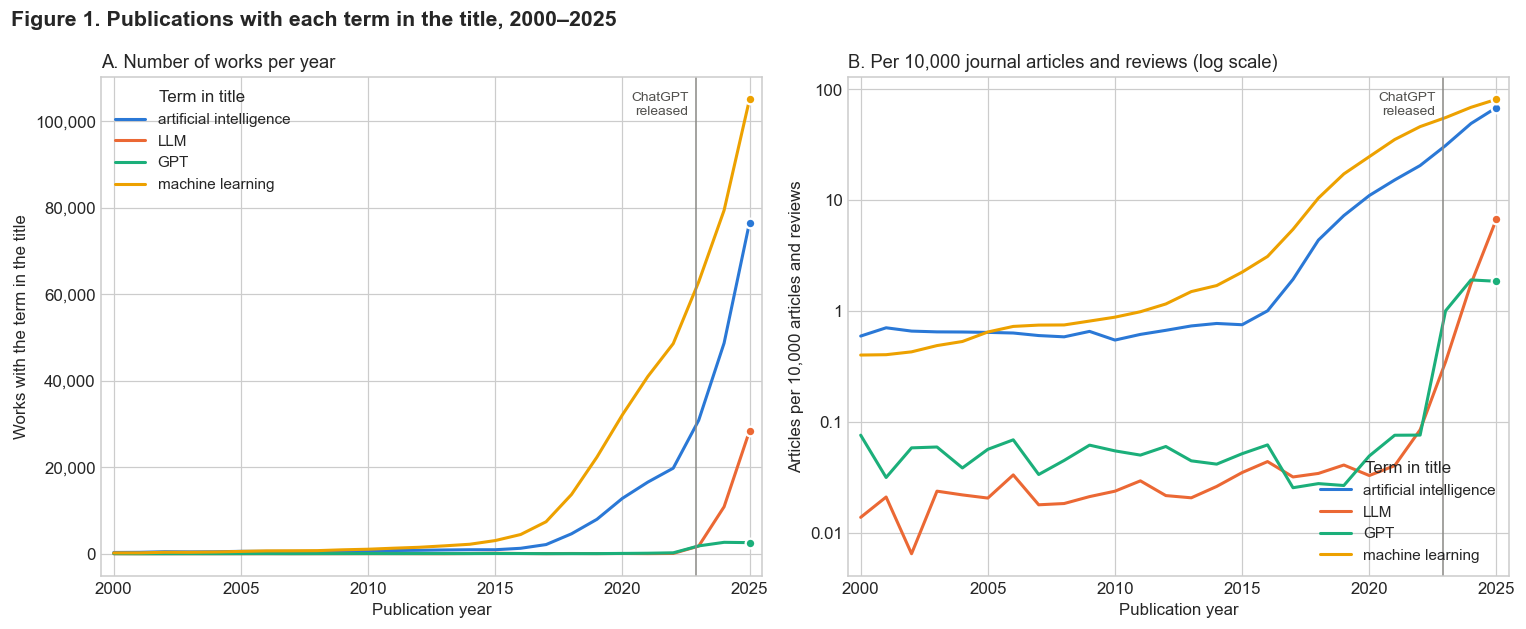

In [18]:
# Articles with the term per 10,000 journal articles and reviews published that year
rate_per_10k = yearly_articles.div(totals.loc[2000:2025, "articles"], axis = 0) * 10000

fig, list_axes = plt.subplots(1, 2, figsize = (14, 5.8))

list_panels = [{"data":   yearly_works,
                "title":  "A. Number of works per year",
                "ylabel": "Works with the term in the title",
                "scale":  "linear",
                "label":  "{:,.0f}"},
               {"data":   rate_per_10k,
                "title":  "B. Per 10,000 journal articles and reviews (log scale)",
                "ylabel": "Articles per 10,000 articles and reviews",
                "scale":  "log",
                "label":  "{:,.1f}"}]

for i in range(2):
    ax    = list_axes[i]
    panel = list_panels[i]
    for keyword in list_keywords:
        values = panel["data"][keyword]
        if panel["scale"] == "log":
            values = values.replace(0, np.nan)         # a log scale cannot show 0
        ax.plot(values.index, values, color = dict_colors[keyword], linewidth = 2, label = keyword)
        ax.scatter(2025, values.loc[2025], color = dict_colors[keyword], s = 40, zorder = 3,
                   edgecolor = "white", linewidth = 1.5)
    ax.set_yscale(panel["scale"])
    ax.axvline(2022.9, color = "#8a8985", linewidth = 1)
    ax.text(2022.6, 0.97, "ChatGPT\nreleased", transform = ax.get_xaxis_transform(),
            ha = "right", va = "top", fontsize = 9, color = "#52514e")
    ax.set_title(panel["title"], loc = "left", fontsize = 12)
    ax.set_xlabel("Publication year")
    ax.set_ylabel(panel["ylabel"])
    ax.set_xlim(1999.5, 2025.5)
    ax.set_xticks(range(2000, 2026, 5))
    ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,g}"))

list_axes[0].legend(title = "Term in title", loc = "upper left")
list_axes[1].legend(title = "Term in title", loc = "lower right")
fig.suptitle("Figure 1. Publications with each term in the title, 2000–2025",
             fontsize = 14, fontweight = "bold", x = 0.01, ha = "left")
fig.tight_layout()
plt.show()

In [19]:
list_show_years = [2000, 2010, 2015, 2020, 2022, 2023, 2024, 2025]

growth = yearly_works.loc[list_show_years].T
growth.columns = [str(year) for year in list_show_years]
growth["Growth 2024 to 2025"]         = (yearly_works.loc[2025] / yearly_works.loc[2024] - 1) * 100
growth["Share of 2000–2025 total published in 2023–2025"] = (yearly_works.loc[2023:2025].sum()
                                                             / yearly_works.sum() * 100)
growth = growth.reset_index().rename(columns = {"keyword": "Term in title"})

dict_format = {}
for year in list_show_years:
    dict_format[str(year)] = "{:,.0f}"
dict_format["Growth 2024 to 2025"] = "{:+.0f}%"
dict_format["Share of 2000–2025 total published in 2023–2025"] = "{:.0f}%"

style_table(growth, "Table 10. Works with each term in the title, selected years", dict_format)

Term in title,2000,2010,2015,2020,2022,2023,2024,2025,Growth 2024 to 2025,Share of 2000–2025 total published in 2023–2025
artificial intelligence,303,617,933,"12,805","19,781","30,828","48,684","76,545",+57%,68%
LLM,4,21,117,62,76,"1,772","10,865","28,384",+161%,98%
GPT,31,52,54,80,221,"1,819","2,646","2,573",-3%,86%
machine learning,199,"1,053","3,054","32,102","48,565","62,806","79,372","105,008",+32%,57%


> ✏️ *To write in your own words.*

## 6. New insight (Questions 5 and 6): Has AI research spread beyond computer science?

> ✏️ *To write in your own words.*

In [20]:
dict_periods = {"2000–2015": "2000-2015",
                "2016–2022": "2016-2022",
                "2023–2025": "2023-2025"}

list_fields = []
list_checks = []
for period in dict_periods:
    years = dict_periods[period]
    name  = years.replace("-", "_")

    ai_groups, n_ai = get_groups({"filter":   filter_ai + ",publication_year:" + years + ",type:article|review",
                                  "group_by": "primary_topic.field.id:include_unknown"},
                                 "q5_fields_ai_" + name)
    all_groups, n_all = get_groups({"filter":   "publication_year:" + years + ",type:article|review",
                                    "group_by": "primary_topic.field.id:include_unknown"},
                                   "q5_fields_all_" + name)

    merged = pd.merge(all_groups.rename(columns = {"count": "papers_all"}),
                      ai_groups[["key", "count"]].rename(columns = {"count": "papers_ai"}),
                      on  = "key",
                      how = "left")
    merged["papers_ai"] = merged["papers_ai"].fillna(0)      # a field with no AI papers
    merged["period"]    = period
    list_fields.append(merged)

    list_checks.append({"Period":                   period,
                        "AI papers":                n_ai,
                        "Sum of AI field groups":   ai_groups["count"].sum(),
                        "AI papers, unknown field": ai_groups.query('key_display_name == "unknown"')["count"].sum(),
                        "All papers":               n_all,
                        "Sum of all field groups":  all_groups["count"].sum(),
                        "Fields":                   len(all_groups.query('key_display_name != "unknown"'))})

fields = pd.concat(list_fields).rename(columns = {"key_display_name": "field"})
fields = fields.query('field != "unknown"').copy()

fields["share_ai"]    = fields["papers_ai"] / fields.groupby("period")["papers_ai"].transform("sum") * 100
fields["ai_per_1000"] = fields["papers_ai"] / fields["papers_all"] * 1000

style_table(pd.DataFrame(list_checks), "Quality check: field groups (journal articles and reviews)",
            {"AI papers": "{:,.0f}", "Sum of AI field groups": "{:,.0f}", "AI papers, unknown field": "{:,.0f}",
             "All papers": "{:,.0f}", "Sum of all field groups": "{:,.0f}", "Fields": "{:.0f}"})

Period,AI papers,Sum of AI field groups,"AI papers, unknown field",All papers,Sum of all field groups,Fields
2000–2015,"4,946","4,946",0,"74,401,892","74,401,892",26
2016–2022,"37,393","37,393",0,"43,507,696","43,507,696",26
2023–2025,"96,998","96,998",0,"19,002,085","19,002,085",26


In [21]:
share_wide = fields.pivot(index = "field", columns = "period", values = "share_ai")
rate_wide  = fields.pivot(index = "field", columns = "period", values = "ai_per_1000")

# The ten fields with the most AI papers in 2023–2025
list_top_fields = share_wide.sort_values("2023–2025", ascending = False).index[0:10]

field_table = pd.DataFrame({
    "Field":                      list_top_fields,
    "Share 2000–2015":            share_wide.loc[list_top_fields, "2000–2015"].values,
    "Share 2016–2022":            share_wide.loc[list_top_fields, "2016–2022"].values,
    "Share 2023–2025":            share_wide.loc[list_top_fields, "2023–2025"].values,
    "Per 1,000 papers 2000–2015": rate_wide.loc[list_top_fields, "2000–2015"].values,
    "Per 1,000 papers 2023–2025": rate_wide.loc[list_top_fields, "2023–2025"].values
})
field_table["Times higher"] = field_table["Per 1,000 papers 2023–2025"] / field_table["Per 1,000 papers 2000–2015"]

style_table(field_table,
            "Table 11. Share of all AI papers by field, and AI papers per 1,000 papers in each field "
            "(journal articles and reviews; ten largest fields in 2023–2025)",
            {"Share 2000–2015": "{:.1f}%", "Share 2016–2022": "{:.1f}%", "Share 2023–2025": "{:.1f}%",
             "Per 1,000 papers 2000–2015": "{:.2f}", "Per 1,000 papers 2023–2025": "{:.2f}",
             "Times higher": "{:,.0f}x"})

Field,Share 2000–2015,Share 2016–2022,Share 2023–2025,"Per 1,000 papers 2000–2015","Per 1,000 papers 2023–2025",Times higher
Medicine,6.5%,28.8%,28.6%,0.03,7.42,276x
Computer Science,36.5%,21.0%,21.4%,0.56,19.41,34x
Social Sciences,4.3%,9.7%,12.1%,0.02,4.12,182x
Engineering,24.1%,12.6%,8.8%,0.07,3.37,48x
"Business, Management and Accounting",4.2%,5.5%,6.7%,0.11,9.88,90x
"Economics, Econometrics and Finance",1.3%,3.5%,3.3%,0.03,6.18,181x
Decision Sciences,3.5%,2.6%,3.0%,0.31,17.02,55x
Environmental Science,4.1%,3.1%,2.5%,0.07,2.55,37x
Psychology,1.7%,1.6%,2.2%,0.05,3.55,70x
Health Professions,1.3%,1.9%,1.8%,0.04,3.46,87x


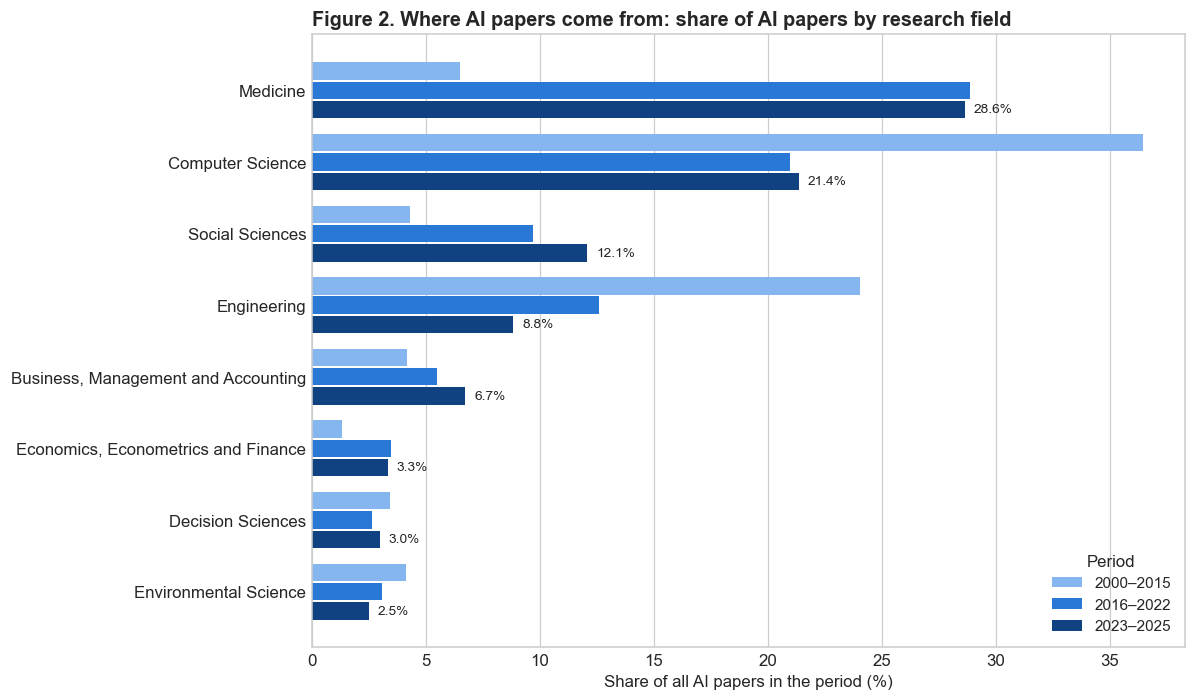

In [22]:
list_plot_fields   = list(list_top_fields[0:8])[::-1]      # largest at the top
list_period_colors = ["#86b6ef", "#2a78d6", "#104281"]     # light = early, dark = recent
positions          = np.arange(len(list_plot_fields))
bar_height         = 0.27

fig, ax = plt.subplots(figsize = (11, 6.5))

index = 0
for period in dict_periods:
    ax.barh(positions - (index - 1) * bar_height, share_wide.loc[list_plot_fields, period],
            height = bar_height * 0.9, color = list_period_colors[index], label = period)
    index = index + 1

for i in range(len(list_plot_fields)):
    value = share_wide.loc[list_plot_fields[i], "2023–2025"]
    ax.text(value + 0.4, positions[i] - bar_height, f"{value:.1f}%", va = "center", fontsize = 9)

ax.set_yticks(positions)
ax.set_yticklabels(list_plot_fields)
ax.set_xlabel("Share of all AI papers in the period (%)")
ax.set_title("Figure 2. Where AI papers come from: share of AI papers by research field",
             loc = "left", fontweight = "bold")
ax.legend(title = "Period", loc = "lower right")
ax.grid(axis = "y", visible = False)
fig.tight_layout()
plt.show()

> ✏️ *To write in your own words.*

## 7. Limitations

> ✏️ *To write in your own words.*

## Appendix: API requests

Every request sent to `https://api.openalex.org/works`, the file it is saved in, and the date it was retrieved.

In [23]:
list_rows = []
for request in list_requests:
    with open(folder_cache + request["file"], "r", encoding = "utf-8") as file:
        retrieved = json.load(file)["retrieved"]
    list_rows.append({"Saved as":  request["file"],
                      "filter":    request["parameters"].get("filter", ""),
                      "group_by":  request["parameters"].get("group_by", ""),
                      "sort":      request["parameters"].get("sort", ""),
                      "Retrieved": retrieved})

requests_table = pd.DataFrame(list_rows).drop_duplicates(subset = "Saved as")
style_table(requests_table, f"Table A1. The {len(requests_table)} requests used in this report", {})

Saved as,filter,group_by,sort,Retrieved
q1_title_phrase.json,"title.search:""artificial intelligence""",,,2026-09-28
q1_title_words.json,title.search:artificial intelligence,,,2026-09-28
q1_by_year.json,"title.search:""artificial intelligence""",publication_year:include_unknown,,2026-09-28
q1_by_type.json,"title.search:""artificial intelligence""",type,,2026-09-28
q2_countries_page1.json,"title.search:""artificial intelligence"",publication_year:2000-2026",authorships.countries:include_unknown,,2026-09-28
q2_countries_page2.json,"title.search:""artificial intelligence"",publication_year:2000-2026",authorships.countries:include_unknown,,2026-09-28
q3_top_cited_any_type.json,"title.search:""artificial intelligence"",publication_year:2000-2026",,cited_by_count:desc,2026-09-28
q3_citing_W4221143046.json,cites:W4221143046,,,2026-09-28
q3_top_cited_papers.json,"title.search:""artificial intelligence"",publication_year:2000-2026,type:article|review",,cited_by_count:desc,2026-09-28
q4_years_artificial_intelligence.json,"title.search:""artificial intelligence"",publication_year:2000-2025",publication_year,,2026-09-28
